<a href="https://colab.research.google.com/github/prometricas/Yonny_Markov/blob/main/Yonny_finance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **1. Importar datos**
* Dejo este bloque como punto de arranque para que el notebook sea reproducible.
* Instalo dependencias mínimas para leer Excel y ajustar modelos más adelante.
* En Colab, monto Google Drive para leer los Excel directamente sin subirlos.

In [135]:
# ============================================================
# (0) Instalación e imports
# ============================================================

!pip -q install openpyxl statsmodels
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
np.set_printoptions(suppress=True)


# ============================================================
# (1) Montaje de Google Drive y rutas de archivos
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

# Carpeta donde están los archivos
DRIVE_FOLDER = "/content/drive/MyDrive/Pigs/Yonny_Markov"
SERIES_FILE = os.path.join(DRIVE_FOLDER, "data_gas_carbón.xlsx")
FLOWS_FILE  = os.path.join(DRIVE_FOLDER, "flujo_caja.xlsx")

print("Ruta series:", SERIES_FILE)
print("Ruta flujos:", FLOWS_FILE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ruta series: /content/drive/MyDrive/Pigs/Yonny_Markov/data_gas_carbón.xlsx
Ruta flujos: /content/drive/MyDrive/Pigs/Yonny_Markov/flujo_caja.xlsx


# **2. Series: gas y carbón**
* En esta versión se asume que el Excel consolidado ya viene “limpio” y con nombres fijos.
* La meta del bloque es dejar un DataFrame mensual, ordenado, sin nulos y listo para retornos.


In [136]:
# Leer archivo de datos
df_prices = pd.read_excel(SERIES_FILE, sheet_name=0)
df_prices["date"] = pd.to_datetime(df_prices["date"])
df_prices = df_prices.sort_values("date").reset_index(drop=True)

# Índice mensual (fin de mes)
df_prices["month"] = df_prices["date"].dt.to_period("M").dt.to_timestamp("M")
df_prices = df_prices.drop(columns=["date"]).set_index("month")

# Frecuencia mensual + limpieza
df_prices = df_prices.asfreq("M").dropna()

# Mostrar dataframe
df_prices.head()

,gas_price,carbon_price
month,,
1997-01-31,3.45,35.23
1997-02-28,2.15,34.60
1997-03-31,1.89,34.50
1997-04-30,2.03,35.40
1997-05-31,2.25,35.73


# **3. Gráficas: niveles de precios**
* Primero exploro “niveles” (precios sin transformar). Esto sirve para: ver tendencias de largo plazo, detectar rupturas visibles, comprobar que no hay valores absurdos (ceros, negativos)
* Mantengo gráficos separados para no mezclar escalas.


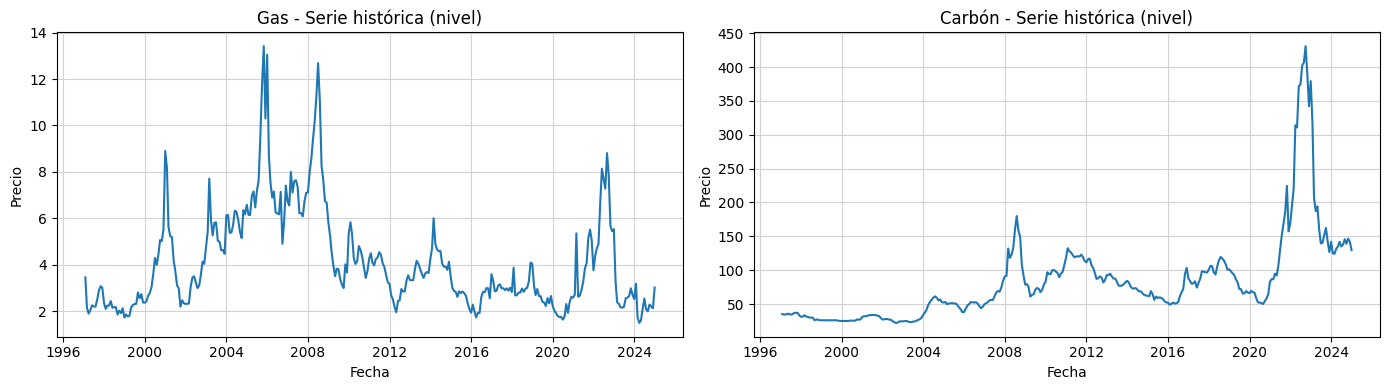

In [137]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=False)

# Gas
axes[0].plot(df_prices.index, df_prices["gas_price"])
axes[0].set_title("Gas - Serie histórica (nivel)")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("Precio")
axes[0].grid(True, color='lightgray')

# Carbón
axes[1].plot(df_prices.index, df_prices["carbon_price"])
axes[1].set_title("Carbón - Serie histórica (nivel)")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("Precio")
axes[1].grid(True, color='lightgray')

plt.tight_layout()
plt.show()

# **4. Retornos y diagnóstico**

Trabajo con log-retornos: r_t = ln(P_t) - ln(P_{t-1})

Este paso es clave porque:
* Acerca la dinámica a supuestos tipo GBM
* Facilita comparar volatilidades entre activos con escalas distintas
* Reduce problemas de heterocedasticidad en “niveles”

En el diagnóstico básico reviso:
* Estadísticos descriptivos
* Series de retornos: comportamiento temporal
* Histogramas: colas / asimetría
* Volatilidad móvil: intuición preliminar de cambios de régimen.

,count,mean,std,min,25%,50%,75%,max
gas_ret,335.0,-0.000407,0.152604,-0.713922,-0.080285,-0.002999,0.087021,0.680148
carbon_ret,335.0,0.003893,0.082870,-0.426985,-0.031985,0.000000,0.043151,0.363734


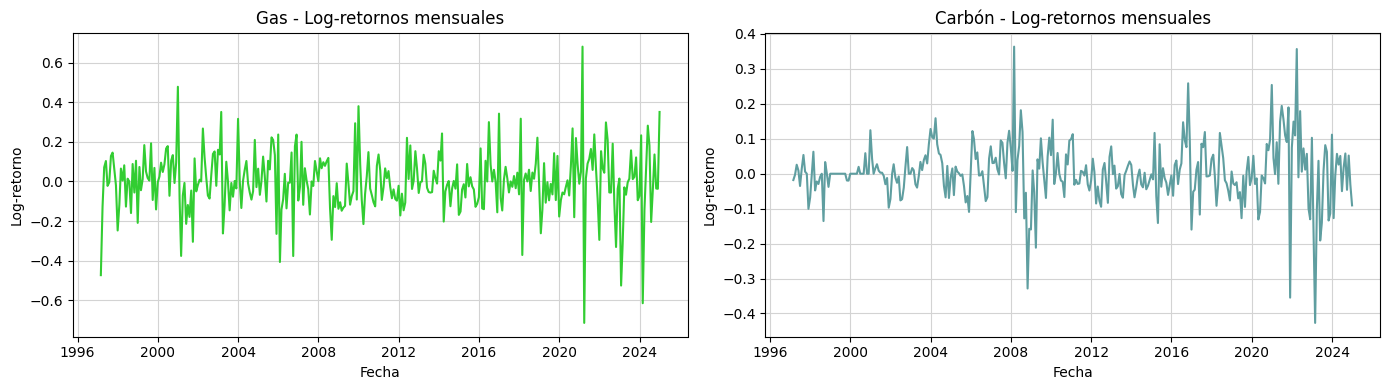

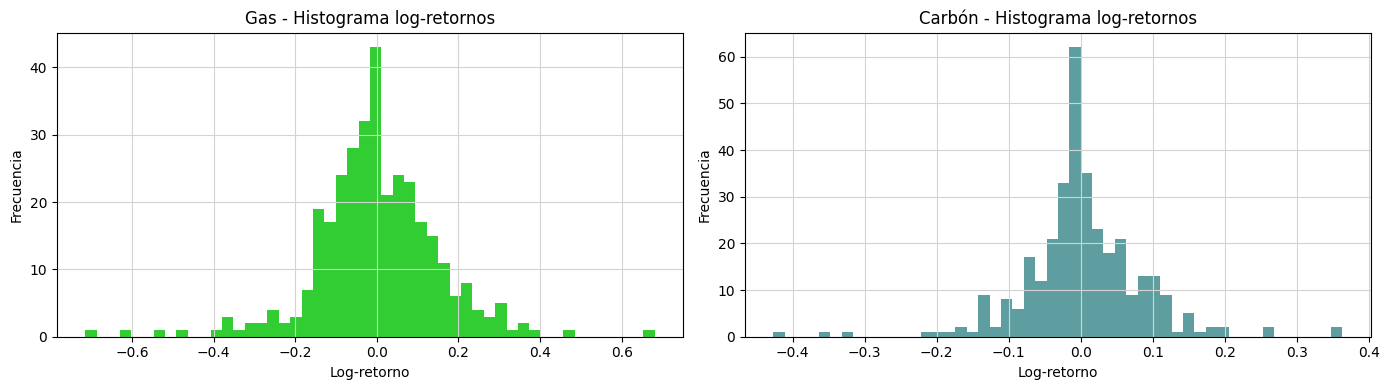

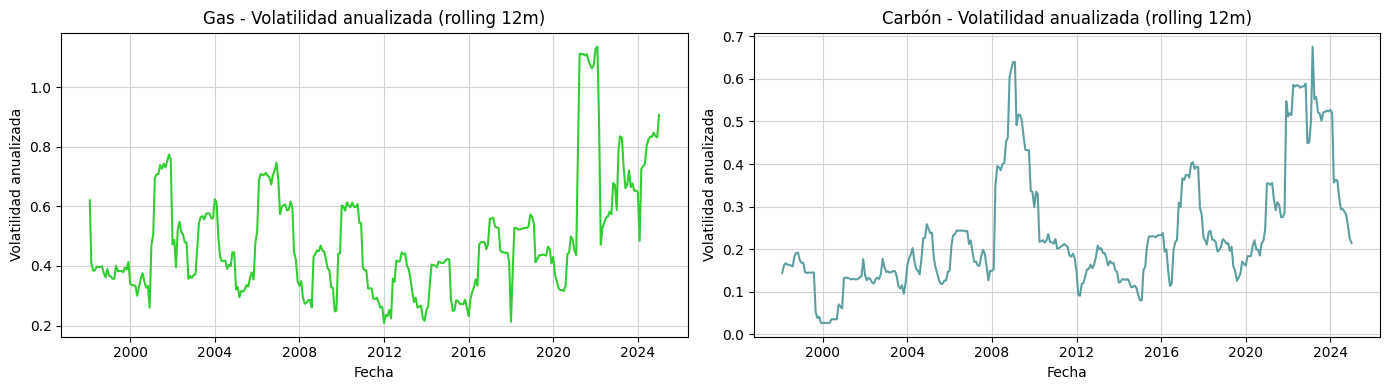

In [138]:
# Resumen numérico
df_rets = np.log(df_prices).diff().dropna()
df_rets.columns = ["gas_ret", "carbon_ret"]
display(df_rets.describe().T)

# Series de log-retornos (lado a lado)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)
axes[0].plot(df_rets.index, df_rets["gas_ret"], color='limegreen')
axes[0].set_title("Gas - Log-retornos mensuales")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("Log-retorno")
axes[0].grid(True, color='lightgray')

axes[1].plot(df_rets.index, df_rets["carbon_ret"], color='cadetblue')
axes[1].set_title("Carbón - Log-retornos mensuales")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("Log-retorno")
axes[1].grid(True, color='lightgray')

plt.tight_layout()
plt.show()

# Histogramas (lado a lado)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_rets["gas_ret"], bins=50, color='limegreen')
axes[0].set_title("Gas - Histograma log-retornos")
axes[0].set_xlabel("Log-retorno")
axes[0].set_ylabel("Frecuencia")
axes[0].grid(True, color='lightgray')

axes[1].hist(df_rets["carbon_ret"], bins=50, color='cadetblue')
axes[1].set_title("Carbón - Histograma log-retornos")
axes[1].set_xlabel("Log-retorno")
axes[1].set_ylabel("Frecuencia")
axes[1].grid(True, color='lightgray')

plt.tight_layout()
plt.show()

# Volatilidad móvil anualizada (lado a lado)
roll = 12
vol_gas_annual = df_rets["gas_ret"].rolling(roll).std() * np.sqrt(12)
vol_car_annual = df_rets["carbon_ret"].rolling(roll).std() * np.sqrt(12)
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

axes[0].plot(vol_gas_annual.index, vol_gas_annual, color='limegreen')
axes[0].set_title("Gas - Volatilidad anualizada (rolling 12m)")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("Volatilidad anualizada")
axes[0].grid(True, color='lightgray')

axes[1].plot(vol_car_annual.index, vol_car_annual, color='cadetblue')
axes[1].set_title("Carbón - Volatilidad anualizada (rolling 12m)")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("Volatilidad anualizada")
axes[1].grid(True, color='lightgray')

plt.tight_layout()
plt.show()

# **5. Modelo Markov-Switching: 2 regímenes**
En esta sección se estima un modelo de cambio de regímenes "_Markov-switching_" directamente sobre los retornos logarítmicos mensuales.

**Idea central:**
- existe un estado no observado s_t ∈ {0,1} (régimen 0 / régimen 1)
- el retorno depende del régimen activo en cada periodo
- secuencia de regímenes sigue una cadena de Markov con matriz de transición P

Este ajuste permite obtener:
- μ_0, μ_1  medias por régimen
- σ_0, σ_1  volatilidades por régimen
- P         probabilidades de pasar de un régimen a otro
- Probs suavizadas P(s_t = k | toda la muestra)

Se usa k=2 regímenes para mantener interpretación simple
- uno suele capturar episodios “tranquilos”
- otro episodios “volátiles”

Nota técnica:
- se multiplica la serie por 100 para estabilizar la optimización numérica
- al final, parámetros se devuelven a la escala original: dividiendo por 100.

**Ecuación de retornos por régimen (forma simple):**

$$
r_t = \mu_{s_t} + \sigma_{s_t}\,\varepsilon_t,\qquad \varepsilon_t \sim \mathcal{N}(0,1)
$$

donde:

- $r_t$ es el log-retorno en $t$.
- $s_t \in \{0,1\}$ es el régimen activo (variable no observada).
- $\mu_{s_t}$ es la media del retorno en el régimen $s_t$.
- $\sigma_{s_t}$ es la volatilidad en el régimen $s_t$.

**Cadena de Markov para regímenes:**

$$
\Pr(s_t=j \mid s_{t-1}=i) = p_{ij}
\quad\Rightarrow\quad
\mathbf{P}=
\begin{pmatrix}
p_{00} & p_{01}\\
p_{10} & p_{11}
\end{pmatrix}
$$

**Duración esperada del régimen $i$:**

$$
\mathbb{E}[D_i] = \frac{1}{1-p_{ii}}
$$

**Lectura típica de parámetros:**
- Si $\sigma_1 \gg \sigma_0$, el régimen 1 suele representar episodios de alta volatilidad.
- Si $p_{00}$ y $p_{11}$ son altos, los regímenes tienden a ser persistentes (cambios poco frecuentes).

**Lectura sugerida de la tabla:**
- $\mu$ expresa el retorno medio mensual en cada régimen (en log-retornos).
- $\sigma$ expresa la volatilidad mensual en cada régimen.
- La duración esperada indica cuántos meses, en promedio, permanece el proceso en un régimen antes de cambiar.

## 5.1. Definir funciones

In [139]:
# Librerías
import statsmodels.api as sm
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression

# -----------------------------
# Ajuste del modelo (gas y carbón)
# -----------------------------
def fit_markov_switching(returns: pd.Series, k_regimes: int = 2):
    # Escalamiento numérico: r_t(%) = 100 * r_t
    y = (returns.dropna() * 100.0)

    model = MarkovRegression(
        y,
        k_regimes=k_regimes,
        trend="c",                 # constante (media) por régimen
        switching_variance=True    # varianza por régimen
    )
    res = model.fit(disp=False)
    return res

ms_gas  = fit_markov_switching(df_rets["gas_ret"], k_regimes=2)
ms_coal = fit_markov_switching(df_rets["carbon_ret"], k_regimes=2)

# Resúmenes (tabla completa del ajuste)
print(ms_gas.summary())
print(ms_coal.summary())


# -----------------------------
# Extracción de parámetros e interpretación operativa
# -----------------------------
def extract_ms_params(res):
    # Matriz de transición (statsmodels entrega p[0->0] y p[1->0] en este modelo)
    p00 = float(res.params["p[0->0]"])
    p10 = float(res.params["p[1->0]"])
    P = np.array([
        [p00, 1.0 - p00],
        [p10, 1.0 - p10]
    ])

    # Medias por régimen (regreso a escala original dividiendo por 100)
    mu0 = float(res.params["const[0]"]) / 100.0
    mu1 = float(res.params["const[1]"]) / 100.0

    # Volatilidades por régimen: sigma = sqrt(sigma2) y regreso a escala original
    s0 = np.sqrt(float(res.params["sigma2[0]"])) / 100.0
    s1 = np.sqrt(float(res.params["sigma2[1]"])) / 100.0

    # Probabilidades suavizadas por régimen
    smoothed = res.smoothed_marginal_probabilities

    # Estado “actual” como última probabilidad suavizada (para iniciar simulaciones después)
    p_last = smoothed.iloc[-1].values
    p_last = p_last / p_last.sum()

    # Duración esperada por régimen: 1/(1-p_ii)
    dur0 = 1.0 / (1.0 - P[0, 0])
    dur1 = 1.0 / (1.0 - P[1, 1])

    return {
        "P": P,
        "mu": np.array([mu0, mu1]),
        "sigma": np.array([s0, s1]),
        "durations": np.array([dur0, dur1]),
        "p0": p_last,
        "smoothed_probs": smoothed
    }

par_gas  = extract_ms_params(ms_gas)
par_coal = extract_ms_params(ms_coal)

# Tabla resumen interpretativa
df_params = pd.DataFrame({
    "Activo": ["Gas", "Gas", "Carbón", "Carbón"],
    "Régimen": [0, 1, 0, 1],
    "mu (mensual)": np.concatenate([par_gas["mu"], par_coal["mu"]]),
    "sigma (mensual)": np.concatenate([par_gas["sigma"], par_coal["sigma"]]),
    "Duración esperada (meses)": np.concatenate([par_gas["durations"], par_coal["durations"]]),
})
display(df_params)

                        Markov Switching Model Results                        
Dep. Variable:                gas_ret   No. Observations:                  335
Model:               MarkovRegression   Log Likelihood               -1362.805
Date:                Mon, 23 Feb 2026   AIC                           2737.611
Time:                        16:40:44   BIC                           2760.495
Sample:                    02-28-1997   HQIC                          2746.734
                         - 12-31-2024                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2045      0.859      0.238      0.812      -1.479       1.888
sigma2       100.3162     21.802      4.601      0.0

,Activo,Régimen,mu (mensual),sigma (mensual),Duración esperada (meses)
0,Gas,0,0.002045,0.100158,7.114621
1,Gas,1,-0.008109,0.253565,2.319916
2,Carbón,0,-0.008240,0.042284,22.651395
3,Carbón,1,0.026175,0.123976,11.770069


## 5.2. Visualizaciones

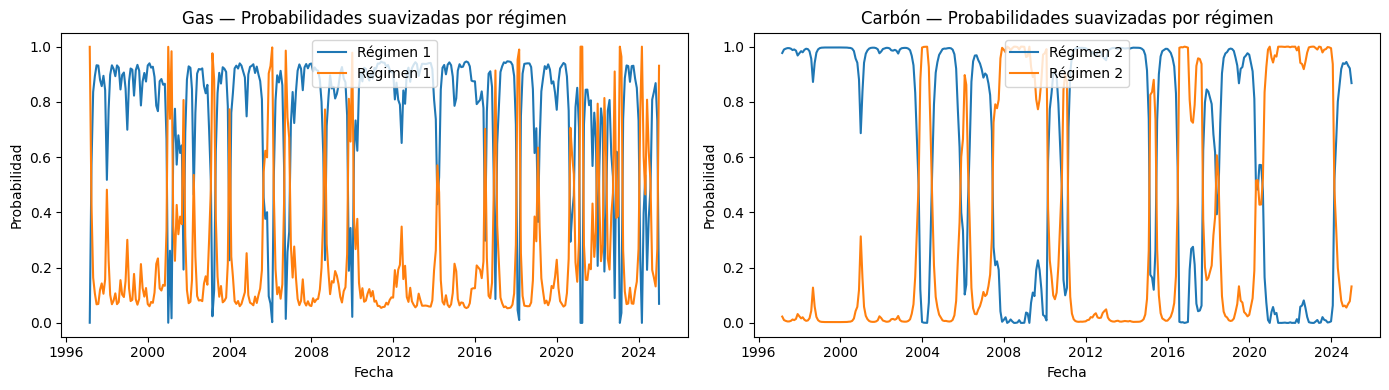

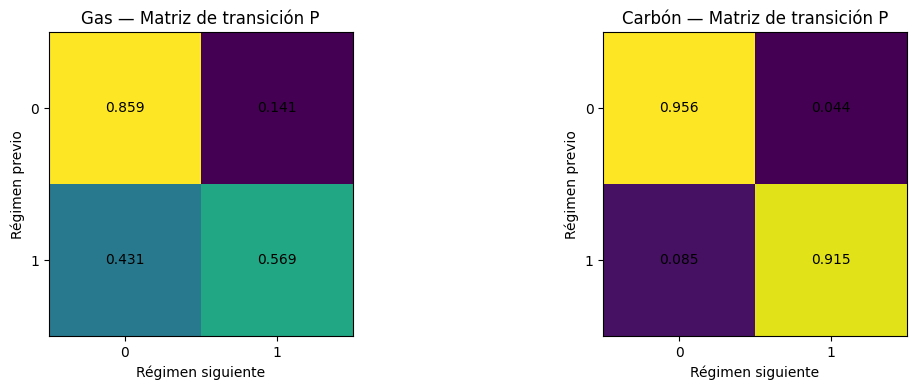

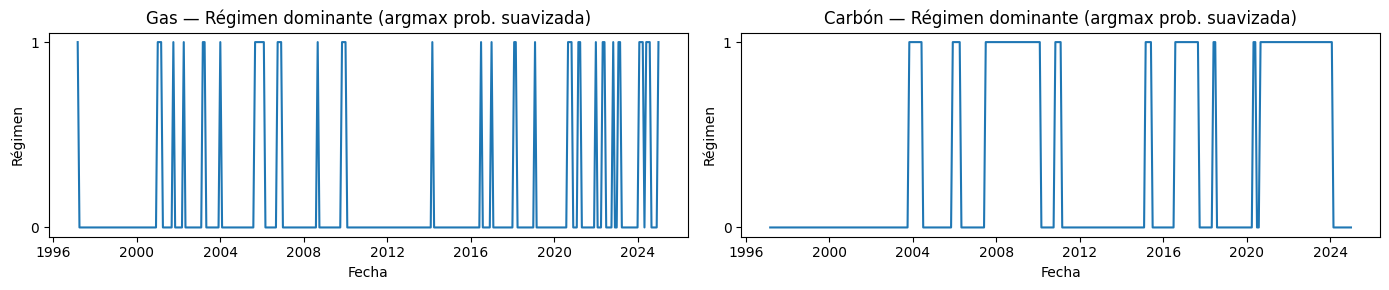

In [140]:
# -----------------------------
# Visualización: probabilidades suavizadas (lado a lado)
# -----------------------------
# Gráfico clave para “ver” los cambios de régimen a través del tiempo:
#   - líneas cercanas a 1 indican alta probabilidad de estar en ese régimen

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

for col in par_gas["smoothed_probs"].columns:
    axes[0].plot(par_gas["smoothed_probs"].index, par_gas["smoothed_probs"][col], label="Régimen 1")
axes[0].set_title("Gas — Probabilidades suavizadas por régimen")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("Probabilidad")
#axes[0].grid(True)
axes[0].legend(loc='upper center')

for col in par_coal["smoothed_probs"].columns:
    axes[1].plot(par_coal["smoothed_probs"].index, par_coal["smoothed_probs"][col], label="Régimen 2")
axes[1].set_title("Carbón — Probabilidades suavizadas por régimen")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("Probabilidad")
#axes[1].grid(True)
axes[1].legend(loc='upper center')


plt.tight_layout()
plt.show()

# -----------------------------
# Visualización: matrices de transición (lado a lado)
# -----------------------------
def plot_transition_matrix(ax, P, title):
    im = ax.imshow(P)
    ax.set_title(title)
    ax.set_xlabel("Régimen siguiente")
    ax.set_ylabel("Régimen previo")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["0", "1"])
    ax.set_yticklabels(["0", "1"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{P[i,j]:.3f}", ha="center", va="center")
    return im

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = plot_transition_matrix(axes[0], par_gas["P"], "Gas — Matriz de transición P")
im1 = plot_transition_matrix(axes[1], par_coal["P"], "Carbón — Matriz de transición P")

#fig.colorbar(im1, ax=axes.ravel().tolist(), shrink=0.9)
plt.tight_layout()
plt.show()


# -----------------------------
# Clasificación “dura” (opcional) y visualización rápida
# -----------------------------
# Esta clasificación toma, en cada fecha, el régimen con probabilidad suavizada máxima.
# Sirve como gráfico de “bandas” para narrar periodos de alta/baja volatilidad.

gas_reg_hard  = par_gas["smoothed_probs"].idxmax(axis=1)
coal_reg_hard = par_coal["smoothed_probs"].idxmax(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 3), sharex=True)

axes[0].plot(gas_reg_hard.index, gas_reg_hard.values)
axes[0].set_title("Gas — Régimen dominante (argmax prob. suavizada)")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("Régimen")
axes[0].set_yticks([0, 1])
#axes[0].grid(True)

axes[1].plot(coal_reg_hard.index, coal_reg_hard.values)
axes[1].set_title("Carbón — Régimen dominante (argmax prob. suavizada)")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("Régimen")
axes[1].set_yticks([0, 1])
#axes[1].grid(True)

plt.tight_layout()
plt.show()

# **6. Simulación GBM con cambio de regímenes: Monte Carlo**

En esta sesión se construyen trayectorias futuras de precios usando:
- un GBM discreto en log-precios, donde μ y σ dependen del régimen activo
- una cadena de Markov que determina cómo cambia el régimen a lo largo del tiempo

**Entradas principales:**
- S0: último precio observado (punto de arranque)
- mu[0], mu[1]: retornos medios mensuales por régimen (estimados en sección 5)
- sigma[0], sigma[1]: volatilidad mensual por régimen
- P: matriz de transición entre regímenes
- p0: probabilidad inicial de estar en cada régimen (tomada del último dato suavizado)

**Salidas:**
- paths: matriz (n_sims x n_steps) con trayectorias de precio
- regimes: matriz (n_sims x n_steps) con el régimen simulado por periodo

In [141]:
# Definir funciones
def simulate_regime_switching_prices(
    S0: float,
    n_steps: int,
    n_sims: int,
    mu: np.ndarray,
    sigma: np.ndarray,
    P: np.ndarray,
    p0: np.ndarray,
    seed: int = 123
):
    rng = np.random.default_rng(seed)

    k = len(mu)

    # Regímenes: matriz de enteros {0,1}
    regimes = np.zeros((n_sims, n_steps), dtype=int)
    regimes[:, 0] = rng.choice(k, size=n_sims, p=p0)

    # Transición de regímenes en el tiempo
    u = rng.random((n_sims, n_steps - 1))
    for t in range(1, n_steps):
        prev = regimes[:, t - 1]
        p_to0 = np.where(prev == 0, P[0, 0], P[1, 0])
        regimes[:, t] = (u[:, t - 1] > p_to0).astype(int)

    # Shocks normales
    Z = rng.standard_normal((n_sims, n_steps))

    # Selección de μ y σ por celda según el régimen
    mu_t = np.where(regimes == 0, mu[0], mu[1])
    s_t  = np.where(regimes == 0, sigma[0], sigma[1])

    # Acumulación de log-precios y transformación a precios
    logS = np.log(S0) + np.cumsum(mu_t + s_t * Z, axis=1)
    S = np.exp(logS)

    return S, regimes


# Horizonte de simulación
# Se usa 2025–2034 como referencia de 10 años -> 120 meses.
years = np.arange(2025, 2035)  # 2025...2034
N_YEARS = len(years)
N_STEPS = N_YEARS * 12

# Número de simulaciones (puede ajustarse; 10k suele ser un estándar de exposición)
N_SIMS = 10000

# Precios iniciales (último valor observado)
last_gas  = float(df_prices["gas_price"].iloc[-1])     # Gas en unidad original del Excel de series
last_coal = float(df_prices["carbon_price"].iloc[-1])  # Carbón en unidad original del Excel de series

# Simulación de trayectorias
gas_paths, gas_reg = simulate_regime_switching_prices(
    S0=last_gas, n_steps=N_STEPS, n_sims=N_SIMS,
    mu=par_gas["mu"], sigma=par_gas["sigma"],
    P=par_gas["P"], p0=par_gas["p0"],
    seed=2025
)

coal_paths, coal_reg = simulate_regime_switching_prices(
    S0=last_coal, n_steps=N_STEPS, n_sims=N_SIMS,
    mu=par_coal["mu"], sigma=par_coal["sigma"],
    P=par_coal["P"], p0=par_coal["p0"],
    seed=2026
)

# Eje temporal mensual para graficar
sim_months = pd.period_range("2025-01", periods=N_STEPS, freq="M").to_timestamp("M")


# **7. Gráficas de simulación**
Trayectorias, bandas percentiles, regímenes
# Se usa:
- trayectorias en gris claro (muchas líneas)
- una  curva resaltada en rojo para el escenario esperado (promedio)
- bandas percentiles en grises (y mediana en rojo)
- series de regímenes en negro / gris oscuro


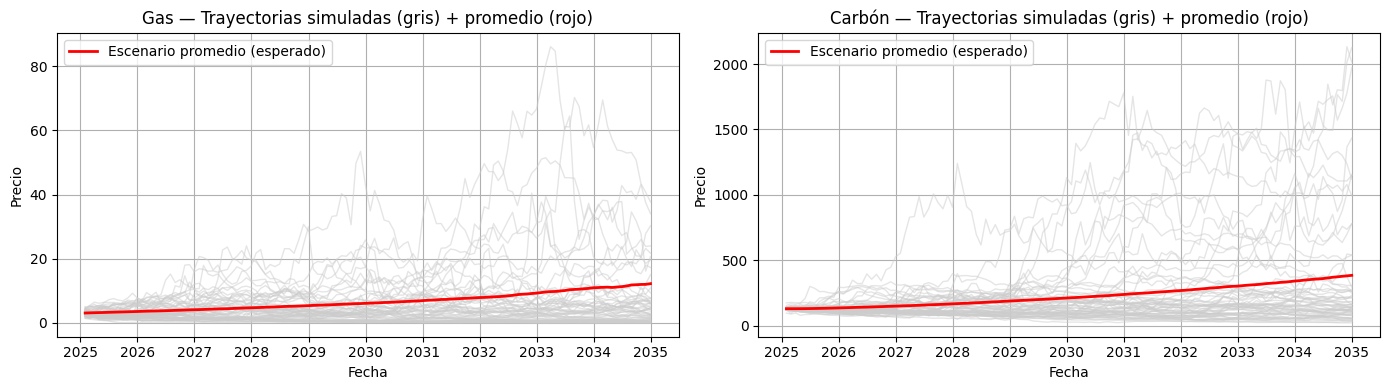

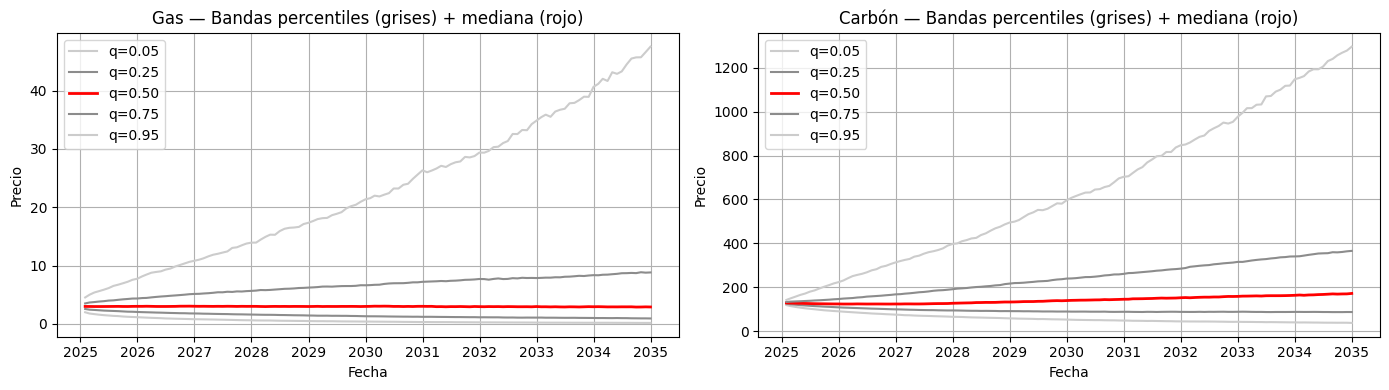

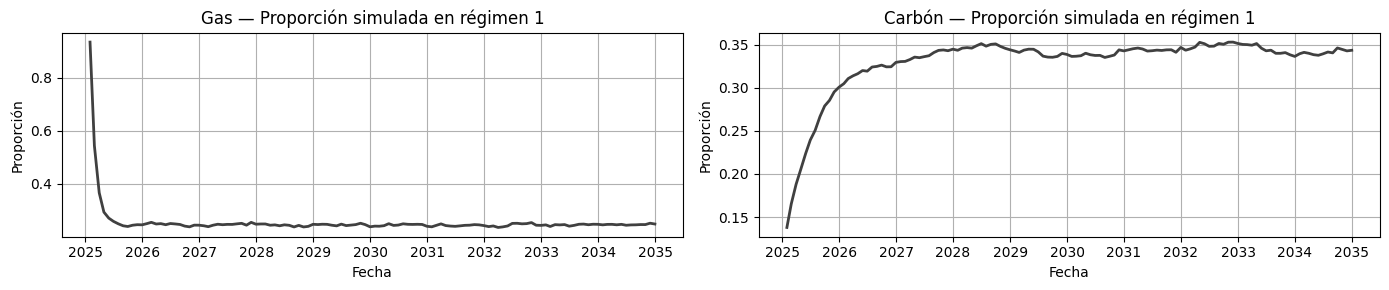

In [142]:
# Paleta en escala de grises (0=negro, 1=blanco)
GRAY_LIGHT   = "0.80"
GRAY_MEDIUM  = "0.55"
GRAY_DARK    = "0.25"
LINE_ALPHA   = 0.50
n_show = 60  # cantidad de trayectorias a mostrar


# Muestra de trayectorias + escenario esperado (promedio)
gas_mean_path  = gas_paths.mean(axis=0)
coal_mean_path = coal_paths.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

for i in range(n_show):
    axes[0].plot(sim_months, gas_paths[i, :], color=GRAY_LIGHT, alpha=LINE_ALPHA, linewidth=1)
axes[0].plot(sim_months, gas_mean_path, color="red", linewidth=2, label="Escenario promedio (esperado)")
axes[0].set_title("Gas — Trayectorias simuladas (gris) + promedio (rojo)")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("Precio")
axes[0].grid(True)
axes[0].legend()

for i in range(n_show):
    axes[1].plot(sim_months, coal_paths[i, :], color=GRAY_LIGHT, alpha=LINE_ALPHA, linewidth=1)
axes[1].plot(sim_months, coal_mean_path, color="red", linewidth=2, label="Escenario promedio (esperado)")
axes[1].set_title("Carbón — Trayectorias simuladas (gris) + promedio (rojo)")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("Precio")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


# Bandas percentiles: fan chart
qs = (0.05, 0.25, 0.50, 0.75, 0.95)

gas_bands  = np.quantile(gas_paths, qs, axis=0)
coal_bands = np.quantile(coal_paths, qs, axis=0)

# Colores grises por cuantil (mediana en rojo)
band_colors = {
    0.05: GRAY_LIGHT,
    0.25: GRAY_MEDIUM,
    0.50: "red",
    0.75: GRAY_MEDIUM,
    0.95: GRAY_LIGHT
}

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

for i, q in enumerate(qs):
    axes[0].plot(
        sim_months, gas_bands[i, :],
        color=band_colors[q],
        linewidth=2 if q == 0.50 else 1.5,
        label=f"q={q:.2f}"
    )
axes[0].set_title("Gas — Bandas percentiles (grises) + mediana (rojo)")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("Precio")
axes[0].grid(True)
axes[0].legend()

for i, q in enumerate(qs):
    axes[1].plot(
        sim_months, coal_bands[i, :],
        color=band_colors[q],
        linewidth=2 if q == 0.50 else 1.5,
        label=f"q={q:.2f}"
    )
axes[1].set_title("Carbón — Bandas percentiles (grises) + mediana (rojo)")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("Precio")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


# Proporción en régimen 1
gas_share_reg1  = gas_reg.mean(axis=0)
coal_share_reg1 = coal_reg.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 3), sharex=True)

axes[0].plot(sim_months, gas_share_reg1, color=GRAY_DARK, linewidth=2)
axes[0].set_title("Gas — Proporción simulada en régimen 1")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("Proporción")
axes[0].grid(True)

axes[1].plot(sim_months, coal_share_reg1, color=GRAY_DARK, linewidth=2)
axes[1].set_title("Carbón — Proporción simulada en régimen 1")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("Proporción")
axes[1].grid(True)

plt.tight_layout()
plt.show()


# **8. Conversión a unidades del flujo de caja**
- Gas: USD/MMBtu -> USD/m3 (÷ 28.33)
- Carbón: USD/ton -> USD/kg (÷ 1000)


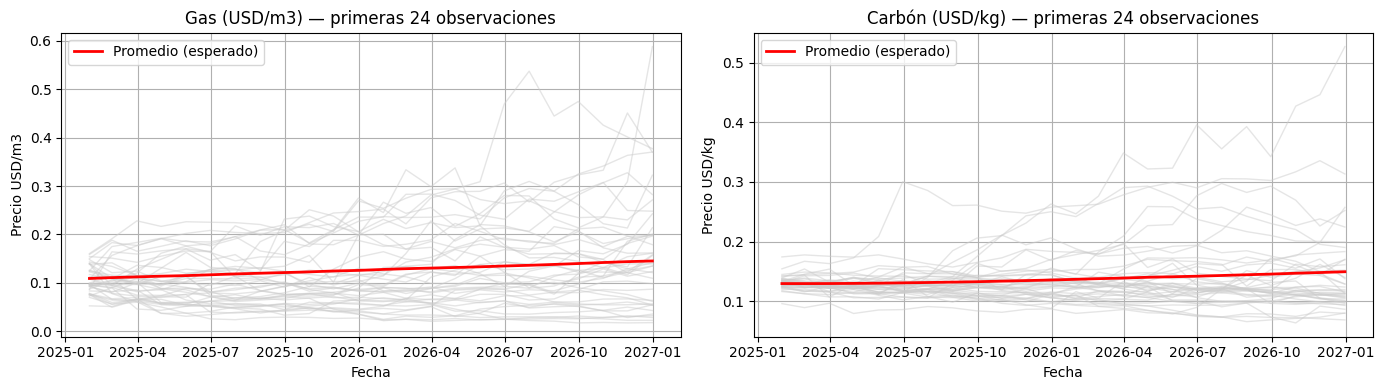

In [143]:
GAS_MMBTU_TO_M3 = 28.33
COAL_TON_TO_KG  = 1000.0

gas_paths_m3  = gas_paths / GAS_MMBTU_TO_M3
coal_paths_kg = coal_paths / COAL_TON_TO_KG

n_show_months = 24
gas_mean_m3   = gas_paths_m3.mean(axis=0)
coal_mean_kg  = coal_paths_kg.mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=False)

for i in range(40):
    axes[0].plot(sim_months[:n_show_months], gas_paths_m3[i, :n_show_months],
                 color=GRAY_LIGHT, alpha=LINE_ALPHA, linewidth=1)
axes[0].plot(sim_months[:n_show_months], gas_mean_m3[:n_show_months],
             color="red", linewidth=2, label="Promedio (esperado)")
axes[0].set_title("Gas (USD/m3) — primeras 24 observaciones")
axes[0].set_xlabel("Fecha")
axes[0].set_ylabel("Precio USD/m3")
axes[0].grid(True)
axes[0].legend()

for i in range(40):
    axes[1].plot(sim_months[:n_show_months], coal_paths_kg[i, :n_show_months],
                 color=GRAY_LIGHT, alpha=LINE_ALPHA, linewidth=1)
axes[1].plot(sim_months[:n_show_months], coal_mean_kg[:n_show_months],
             color="red", linewidth=2, label="Promedio (esperado)")
axes[1].set_title("Carbón (USD/kg) — primeras 24 observaciones")
axes[1].set_xlabel("Fecha")
axes[1].set_ylabel("Precio USD/kg")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

# **9. Lectura flujos de caja desde Excel**
En esta sección se conectan los precios simulados con el modelo financiero.

**Objetivo**
- Leer las hojas del Excel de flujos y Extraer, por etiquetas, las series anuales necesarias para el modelo:
* (a) flujo de caja base (determinístico) por escenario
* (b) cantidades anuales de combustible (m3 gas / kg carbón)
* (c) precio unitario base (USD/m3 gas / USD/kg carbón)
* (d) costo anual base de combustible (cantidad * precio)

**Resultado:**
- Series indexadas por año (2025...2034) listas para:
- Validar coherencia del Excel
- Reemplazar el costo de combustible por el costo simulado (Monte Carlo)

Nota:
- Se incluyen funciones auxiliares para extraer filas por “texto etiqueta”
- Se detectan automáticamente columnas de años para no depender de posiciones fijas


Gas -> fila años: 1 | años detectados: [2025, 2026, 2027, 2028, 2029] ... [2032, 2033, 2034]
Carbón -> fila años: 1 | años detectados: [2025, 2026, 2027, 2028, 2029] ... [2032, 2033, 2034]
Años comunes: [2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034]


,Gas_FCF_base,Gas_qty_m3,Gas_unit_USD_m3,Gas_cost_base
2025,4.939064e+06,1.674046e+06,0.106601,178454.552944
2026,4.165656e+06,1.724267e+06,0.106884,184296.240619
2027,4.289966e+06,1.775995e+06,0.107168,190329.155216
2028,4.418009e+06,1.829275e+06,0.107452,196559.556524
2029,4.549880e+06,1.884153e+06,0.107737,202993.909247
2030,4.685694e+06,1.940678e+06,0.108024,209638.889710
2031,4.830269e+06,2.000839e+06,0.108310,216711.588311
2032,4.979319e+06,2.062865e+06,0.108598,224022.902302
2033,5.137962e+06,2.128876e+06,0.108886,231805.499710
2034,5.301672e+06,2.197000e+06,0.109175,239858.466004


,Coal_FCF_base,Coal_qty_kg,Coal_unit_USD_kg,Coal_cost_base
2025,3.886989e+06,2.349153e+06,0.129810,304943.498865
2026,3.993679e+06,2.419627e+06,0.129925,314369.552373
2027,4.116659e+06,2.492216e+06,0.130040,324086.972923
2028,4.243299e+06,2.566982e+06,0.130155,334104.766907
2029,4.373668e+06,2.643992e+06,0.130270,344432.219114
2030,4.507882e+06,2.723312e+06,0.130385,355078.901334
2031,4.650648e+06,2.807734e+06,0.130500,366410.074123
2032,4.797791e+06,2.894774e+06,0.130616,378102.843944
2033,4.954291e+06,2.987407e+06,0.130731,390547.187171
2034,5.136802e+06,3.083004e+06,0.130847,403401.105943


Chequeo Gas | max(|qty*unit - cost|): 0.0
Chequeo Carbón | max(|qty*unit - cost|): 0.0


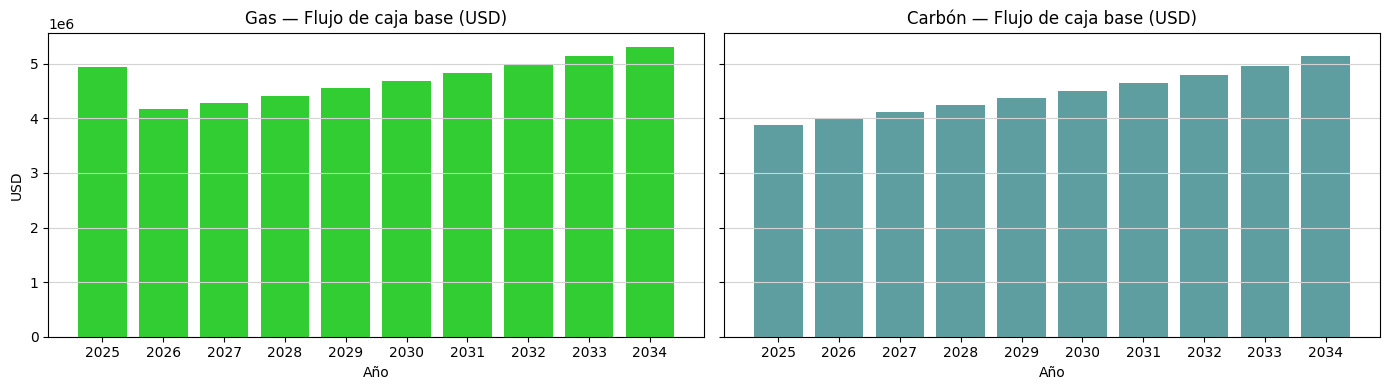

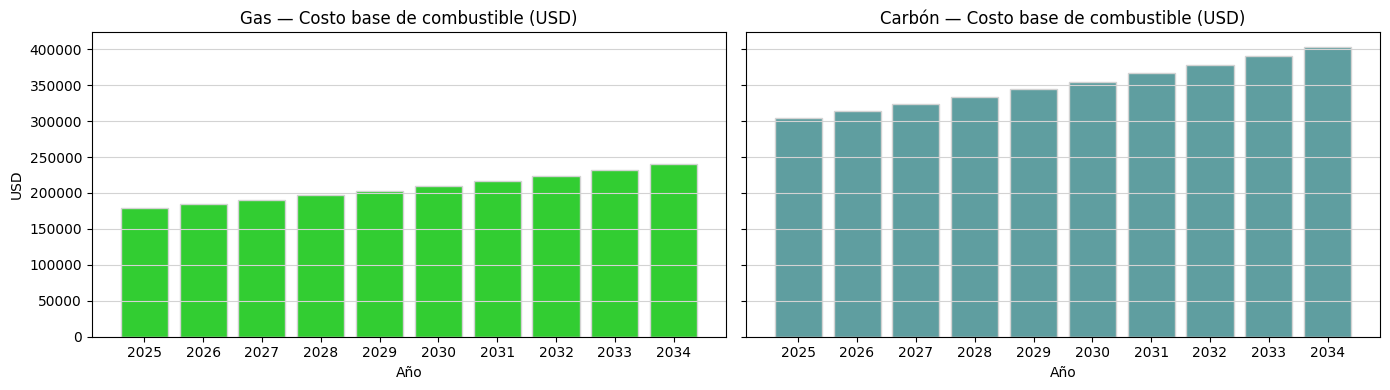

In [144]:
# -----------------------------
# (9.1) Lectura de hojas clave
# -----------------------------
df_gas_raw = pd.read_excel(FLOWS_FILE, sheet_name="FC Gas Inversión", header=None)
df_coa_raw = pd.read_excel(FLOWS_FILE, sheet_name="FC Carbon", header=None)

# -----------------------------
# (9.2) Detección automática de la fila de años y columnas de años
# -----------------------------
def find_year_row_and_cols(df, year_min=2000, year_max=2100, min_years=5):
    """
    Busca una fila con varios años (enteros) para identificar:
      - year_row: fila donde están los años
      - year_cols: columnas donde aparecen los años
    """
    best = None
    for r in range(df.shape[0]):
        row = df.iloc[r, :].values
        cols = []
        years = []
        for c, v in enumerate(row):
            try:
                iv = int(v)
                if year_min <= iv <= year_max:
                    cols.append(c)
                    years.append(iv)
            except:
                continue

        # Heurística simple: suficiente cantidad de años y al menos parcialmente ordenados
        if len(years) >= min_years:
            # Se privilegia la fila con más años detectados
            if (best is None) or (len(years) > len(best[1])):
                best = (r, cols, years)

    if best is None:
        raise ValueError("No se encontró una fila con años. Revisar estructura de la hoja.")
    return best[0], best[1], best[2]


gas_year_row, gas_year_cols, gas_years = find_year_row_and_cols(df_gas_raw)
coa_year_row, coa_year_cols, coa_years = find_year_row_and_cols(df_coa_raw)

print("Gas -> fila años:", gas_year_row, "| años detectados:", gas_years[:5], "...", gas_years[-3:])
print("Carbón -> fila años:", coa_year_row, "| años detectados:", coa_years[:5], "...", coa_years[-3:])

# Alineación: se toma el conjunto de años comunes para operar comparables
years_common = sorted(list(set(gas_years).intersection(set(coa_years))))
print("Años comunes:", years_common)


# -----------------------------
# (9.3) Extracción de series por etiqueta
# -----------------------------
def extract_series_by_label(df, label, year_row, year_cols, label_col=1):
    """
    Encuentra la fila donde la columna label_col coincide con `label` (case-insensitive),
    y extrae valores en columnas year_cols, indexando con los años que están en year_row.
    """
    label_norm = str(label).strip().lower()

    idx = None
    for i, v in df[label_col].items():
        if isinstance(v, str) and v.strip().lower() == label_norm:
            idx = i
            break
    if idx is None:
        raise ValueError(f"No se encontró la etiqueta exacta: '{label}' (columna {label_col}).")

    years = df.iloc[year_row, year_cols].astype(int).values
    vals  = df.iloc[idx, year_cols].astype(float).values
    return pd.Series(vals, index=years).sort_index()


# Etiquetas esperadas (de acuerdo con el Excel del proyecto)
gas_labels = {
    "fcf":       "Flujo de caja neto",
    "qty":       "m3 totales requeridos",
    "unit":      "Precio unitario Gas (USD/m3)",
    "fuel_cost": "Combustible caldera gas natural"
}
coa_labels = {
    "fcf":       "Flujo de caja",
    "qty":       "Kilogramos totales requeridos",
    "unit":      "Costo KG / USD",
    "fuel_cost": "Combustible caldera carbon"
}

# Extracción (Gas)
gas_fcf_base   = extract_series_by_label(df_gas_raw, gas_labels["fcf"], gas_year_row, gas_year_cols)
gas_qty        = extract_series_by_label(df_gas_raw, gas_labels["qty"], gas_year_row, gas_year_cols)
gas_unit_base  = extract_series_by_label(df_gas_raw, gas_labels["unit"], gas_year_row, gas_year_cols)
gas_cost_base  = extract_series_by_label(df_gas_raw, gas_labels["fuel_cost"], gas_year_row, gas_year_cols)

# Extracción (Carbón)
coa_fcf_base   = extract_series_by_label(df_coa_raw, coa_labels["fcf"], coa_year_row, coa_year_cols)
coa_qty        = extract_series_by_label(df_coa_raw, coa_labels["qty"], coa_year_row, coa_year_cols)
coa_unit_base  = extract_series_by_label(df_coa_raw, coa_labels["unit"], coa_year_row, coa_year_cols)
coa_cost_base  = extract_series_by_label(df_coa_raw, coa_labels["fuel_cost"], coa_year_row, coa_year_cols)

# Recorte a años comunes (para comparaciones limpias)
gas_fcf_base  = gas_fcf_base.loc[years_common]
gas_qty       = gas_qty.loc[years_common]
gas_unit_base = gas_unit_base.loc[years_common]
gas_cost_base = gas_cost_base.loc[years_common]

coa_fcf_base  = coa_fcf_base.loc[years_common]
coa_qty       = coa_qty.loc[years_common]
coa_unit_base = coa_unit_base.loc[years_common]
coa_cost_base = coa_cost_base.loc[years_common]

# Tablas resumen
display(pd.DataFrame({
    "Gas_FCF_base": gas_fcf_base,
    "Gas_qty_m3": gas_qty,
    "Gas_unit_USD_m3": gas_unit_base,
    "Gas_cost_base": gas_cost_base
}))

display(pd.DataFrame({
    "Coal_FCF_base": coa_fcf_base,
    "Coal_qty_kg": coa_qty,
    "Coal_unit_USD_kg": coa_unit_base,
    "Coal_cost_base": coa_cost_base
}))


# -----------------------------
# (9.4) Validaciones rápidas de coherencia interna (cantidad * precio = costo)
# -----------------------------
gas_err  = (gas_qty * gas_unit_base - gas_cost_base).abs().max()
coal_err = (coa_qty * coa_unit_base - coa_cost_base).abs().max()

print("Chequeo Gas | max(|qty*unit - cost|):", float(gas_err))
print("Chequeo Carbón | max(|qty*unit - cost|):", float(coal_err))


# -----------------------------
# (9.5) Gráficas lado a lado

# (a) Flujos base
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

axes[0].bar(gas_fcf_base.index.astype(str), gas_fcf_base.values, color='limegreen')
axes[0].set_title("Gas — Flujo de caja base (USD)")
axes[0].set_xlabel("Año")
axes[0].set_ylabel("USD")
axes[0].grid(True, axis="y", color='lightgray')

axes[1].bar(coa_fcf_base.index.astype(str), coa_fcf_base.values, color='cadetblue')
axes[1].set_title("Carbón — Flujo de caja base (USD)")
axes[1].set_xlabel("Año")
axes[1].grid(True, axis="y", color='lightgray')

plt.tight_layout()
plt.show()

# (b) Costos base de combustible
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

axes[0].bar(gas_cost_base.index.astype(str), gas_cost_base.values, color='limegreen', edgecolor='lightgray')
axes[0].set_title("Gas — Costo base de combustible (USD)")
axes[0].set_xlabel("Año")
axes[0].set_ylabel("USD")
axes[0].grid(True, axis="y", color='lightgray')

axes[1].bar(coa_cost_base.index.astype(str), coa_cost_base.values, color='cadetblue', edgecolor='lightgray')
axes[1].set_title("Carbón — Costo base de combustible (USD)")
axes[1].set_xlabel("Año")
axes[1].grid(True, axis="y", color='lightgray')

plt.tight_layout()
plt.show()

# **10. Tasas (RF y WACC) + verificación de VPN base (Gas vs Carbón**
En esta sesión se extraen tasas desde la hoja "WACC" del Excel de flujos:
- RF (tasa libre de riesgo en USD): para probabilidades neutrales al riesgo en el árbol
- WACC (costo de capital en USD): para contrastar (VPN financiero “tradicional”)

También se recalcula el VPN base (determinístico) con descuento anual, tomando:
- 2025 como t=1, 2026 como t=2, ..., 2034 como t=10

WACC (USD): 0.10707456940778887
RF (USD): 0.002651700617840147


,Escenario,VPN con WACC (USD),VPN con RF (USD)
0,Gas,2.779483e+07,4.659555e+07
1,Carbón,2.595588e+07,4.398753e+07


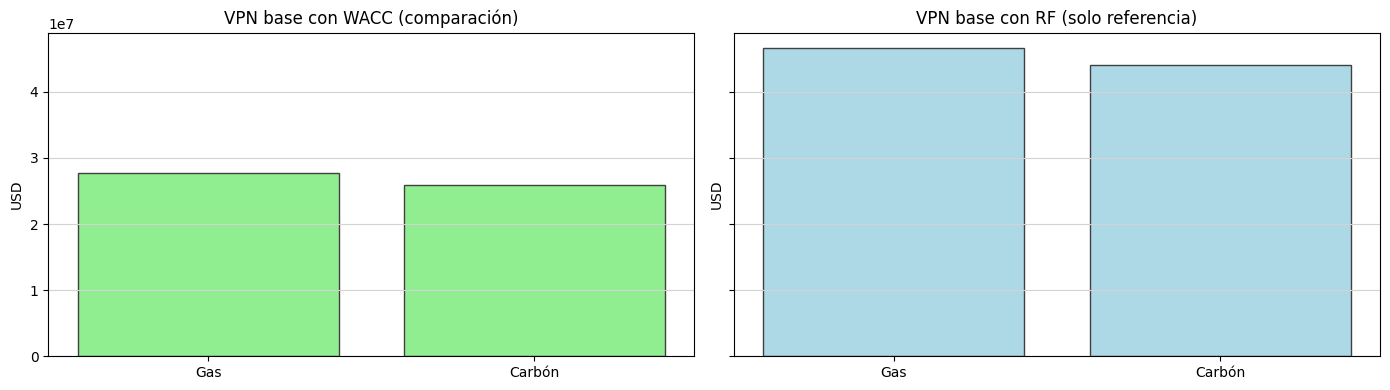

In [145]:
df_wacc_raw = pd.read_excel(FLOWS_FILE, sheet_name="WACC", header=None)
#display(df_wacc_raw.head(12))

def get_value_by_label(df, label, label_col=1, value_col=2):
    label_norm = str(label).strip().lower()
    for i, v in df[label_col].items():
        if isinstance(v, str) and v.strip().lower() == label_norm:
            return float(df.loc[i, value_col])
    raise ValueError(f"No se encontró la etiqueta: '{label}' en la hoja WACC.")

WACC_USD = get_value_by_label(df_wacc_raw, "Costo de Capital en USD")
RF_USD   = get_value_by_label(df_wacc_raw, "Tasa libre de riesgo (RF)")

print("WACC (USD):", WACC_USD)
print("RF (USD):", RF_USD)

def npv_discount_annual(cf: pd.Series, r: float):
    vals = cf.values
    t = np.arange(1, len(vals) + 1)
    return float(np.sum(vals / ((1 + r) ** t)))

vpn_gas_wacc = npv_discount_annual(gas_fcf_base, WACC_USD)
vpn_coa_wacc = npv_discount_annual(coa_fcf_base, WACC_USD)

vpn_gas_rf = npv_discount_annual(gas_fcf_base, RF_USD)
vpn_coa_rf = npv_discount_annual(coa_fcf_base, RF_USD)

df_vpn_check = pd.DataFrame({
    "Escenario": ["Gas", "Carbón"],
    "VPN con WACC (USD)": [vpn_gas_wacc, vpn_coa_wacc],
    "VPN con RF (USD)":   [vpn_gas_rf, vpn_coa_rf],
})
display(df_vpn_check)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
axes[0].bar(["Gas", "Carbón"], [vpn_gas_wacc, vpn_coa_wacc], color='lightgreen', edgecolor="0.25")
axes[0].set_title("VPN base con WACC (comparación)")
axes[0].set_ylabel("USD")
axes[0].grid(True, axis="y", color='lightgray')

axes[1].bar(["Gas", "Carbón"], [vpn_gas_rf, vpn_coa_rf], color='lightblue', edgecolor="0.25")
axes[1].set_title("VPN base con RF (solo referencia)")
axes[1].set_ylabel("USD")
axes[1].grid(True, axis="y", color='lightgray')

plt.tight_layout()
plt.show()

# **11. Árbol binomial NO homogéneo: parámetros por año a partir de Markov-switching**
En esta sesión se construye un árbol binomial por año donde:
- la volatilidad cambia con el tiempo (no homogéneo)
- u_t y d_t se recalculan cada año con sigma_t (CRR no homogéneo)
- p_t se calcula con RF: probabilidad neutral al riesgo por periodo.

En la práctica:
1. se obtiene sigma anual esperada por año usando probabilidades de régimen proyectadas
2. se calcula u_t = exp(sigma_t * sqrt(dt)), d_t = 1/u_t
3. se calcula p_t = (exp(r*dt) - d_t) / (u_t - d_t)


,year,p_reg0,p_reg1,sigma_annual_expected,u_t,d_t,p_t
0,2025,0.069215,0.930785,0.852332,2.345110,0.426419,0.300328
1,2026,0.460702,0.539298,0.686695,1.987137,0.503237,0.336558
2,2027,0.628412,0.371588,0.601950,1.825675,0.547743,0.355976
3,2028,0.700258,0.299742,0.561747,1.753734,0.570212,0.365387
4,2029,0.731037,0.268963,0.543616,1.722223,0.580645,0.369673
5,2030,0.744222,0.255778,0.535661,1.708576,0.585283,0.371561
6,2031,0.749871,0.250129,0.532216,1.702702,0.587302,0.372381
7,2032,0.752290,0.247710,0.530734,1.700180,0.588173,0.372734
8,2033,0.753327,0.246673,0.530098,1.699098,0.588548,0.372885
9,2034,0.753771,0.246229,0.529825,1.698635,0.588708,0.372950


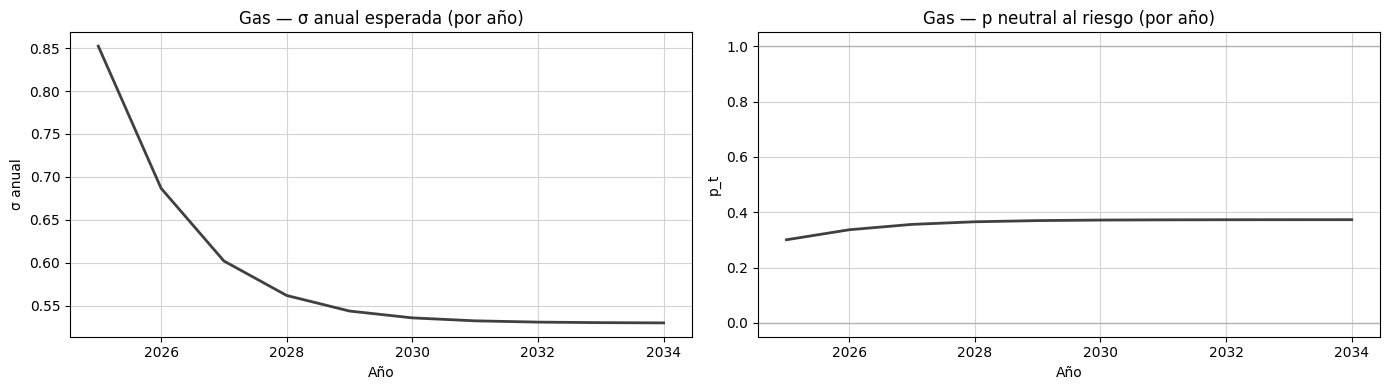

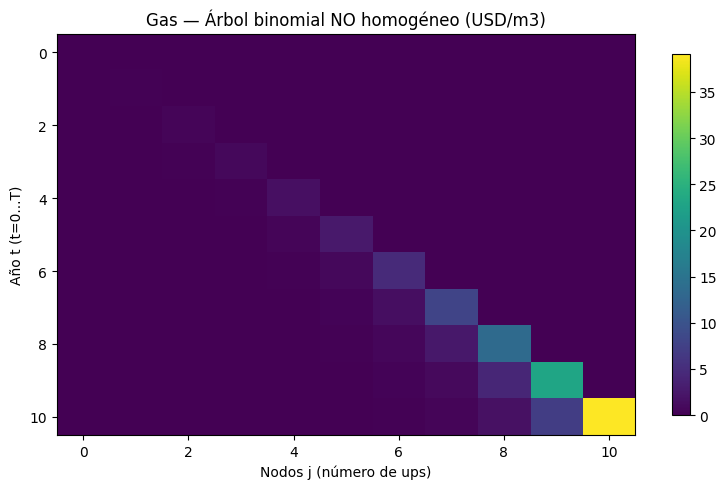

In [146]:

def forecast_regime_probs(P, p_start, n_periods):
    probs = np.zeros((n_periods, len(p_start)))
    probs[0] = p_start
    for t in range(1, n_periods):
        probs[t] = probs[t-1] @ P
    return probs

def build_nonhomog_params_from_markov(P, p0, sigma_monthly_regimes, years, dt_years=1.0):
    # sigma por régimen (mensual) -> sigma por régimen (anual)
    sigma_annual_reg = sigma_monthly_regimes * np.sqrt(12)

    # probabilidades por año (proyección simple usando la matriz P)
    probs = forecast_regime_probs(P, p0, len(years))

    # sigma anual esperada por año: sqrt( sum_k p_k * sigma_k^2 )
    sigma_t = np.sqrt((probs * (sigma_annual_reg**2)).sum(axis=1))

    # CRR no homogéneo
    u_t = np.exp(sigma_t * np.sqrt(dt_years))
    d_t = 1.0 / u_t

    return pd.DataFrame({
        "year": years,
        "p_reg0": probs[:, 0],
        "p_reg1": probs[:, 1],
        "sigma_annual_expected": sigma_t,
        "u_t": u_t,
        "d_t": d_t
    })

# Parámetros no homogéneos para GAS (en unidades del flujo: USD/m3)
# El árbol del combustible debe estar en la unidad usada en los costos anuales.
# Punto inicial S0 = precio unitario base 2025 (USD/m3).
S0_gas = float(gas_unit_base.loc[years_common[0]])

tree_gas_params = build_nonhomog_params_from_markov(
    P=par_gas["P"],
    p0=par_gas["p0"],
    sigma_monthly_regimes=par_gas["sigma"],
    years=np.array(years_common),
    dt_years=1.0
)

# Probabilidad neutral al riesgo por año
dt = 1.0
tree_gas_params["p_t"] = (np.exp(RF_USD * dt) - tree_gas_params["d_t"]) / (tree_gas_params["u_t"] - tree_gas_params["d_t"])

# Control: p_t debe estar entre 0 y 1 en un árbol bien definido (si no, revisar sigma/dt/r)
display(tree_gas_params)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharex=True)

axes[0].plot(tree_gas_params["year"], tree_gas_params["sigma_annual_expected"], color="0.25", linewidth=2)
axes[0].set_title("Gas — σ anual esperada (por año)")
axes[0].set_xlabel("Año")
axes[0].set_ylabel("σ anual")
axes[0].grid(True, color='lightgray')

axes[1].plot(tree_gas_params["year"], tree_gas_params["p_t"], color="0.25", linewidth=2)
axes[1].axhline(0, color="0.7", linewidth=1)
axes[1].axhline(1, color="0.7", linewidth=1)
axes[1].set_title("Gas — p neutral al riesgo (por año)")
axes[1].set_xlabel("Año")
axes[1].set_ylabel("p_t")
axes[1].grid(True, color='lightgray')

plt.tight_layout()
plt.show()


# Construcción del árbol recombinante NO homogéneo (precios por año)
def build_nonhomog_price_tree(S0, u_t, d_t):
    """
    Árbol recombinante con u_t y d_t dependientes solo del tiempo:
      - niveles t = 0..T
      - nodos j = 0..t
    """
    T = len(u_t)  # número de pasos (años)
    S = np.zeros((T + 1, T + 1))
    S[0, 0] = S0

    for t in range(1, T + 1):
        # primer nodo (j=0): solo caídas en ese paso
        S[t, 0] = S[t - 1, 0] * d_t[t - 1]
        # nodos internos: vienen de un "up" desde (t-1, j-1)
        for j in range(1, t + 1):
            S[t, j] = S[t - 1, j - 1] * u_t[t - 1]
    return S

gas_tree_price = build_nonhomog_price_tree(
    S0=S0_gas,
    u_t=tree_gas_params["u_t"].values,
    d_t=tree_gas_params["d_t"].values
)

# Visualización compacta del árbol de precios (heatmap en grises)
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
im = ax.imshow(gas_tree_price, aspect="auto")
ax.set_title("Gas — Árbol binomial NO homogéneo (USD/m3)")
ax.set_xlabel("Nodos j (número de ups)")
ax.set_ylabel("Año t (t=0...T)")
fig.colorbar(im, ax=ax, shrink=0.9)
plt.tight_layout()
plt.show()




# **12. Opción americana de "switch" Gas -> Carbón (abandono = volver a carbón**

Implemento una opción real donde en cada nodo del árbol del GAS existe la decisión:
- Continuar con GAS
- Cambiar a CARBÓN (switch), y permanecer en CARBÓN desde ese momento

En lugar de un salvamento K fijo, la alternativa al ejercicio es el valor del escenario CARBÓN desde el año t en adelante, menos un costo de cambio (switch_cost).

**Punto técnico clave para que el árbol sea consistente:**
- Ajusto SOLO el flujo del año t usando el precio del nodo (no ajusto todos los años futuros con el mismo precio)
- El valor futuro se captura con backward induction sobre los nodos t+1

**Simplificación consciente:**
- La incertidumbre del lado CARBÓN se deja determinística (usa el FCF base de carbón).
- Si se desea, luego puede ampliarse con un segundo árbol (carbón) y un lattice 2D.

CAPEX estimado (a partir del sheet): 936743.9294736843
Switch cost (10% CAPEX): 93674.39294736844


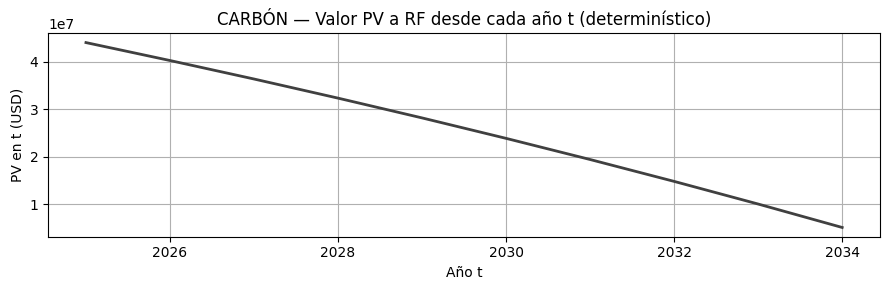

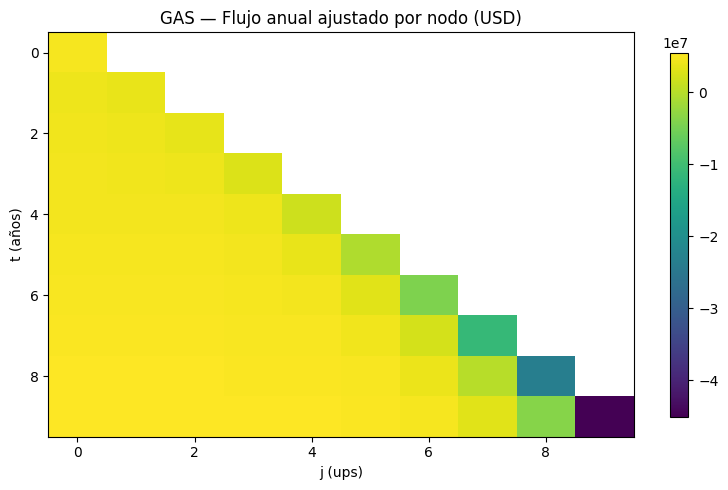

Valor GAS sin opción (PV a RF, t=0): 47107804.44138823
Valor con opción de switch (t=0):     47392663.68882861
Prima de la flexibilidad (>=0):       284859.24744038284


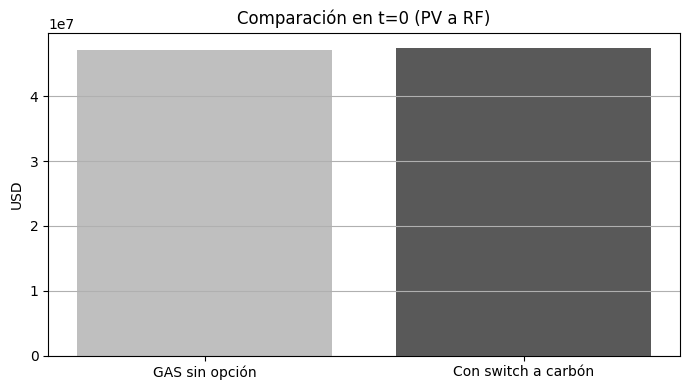

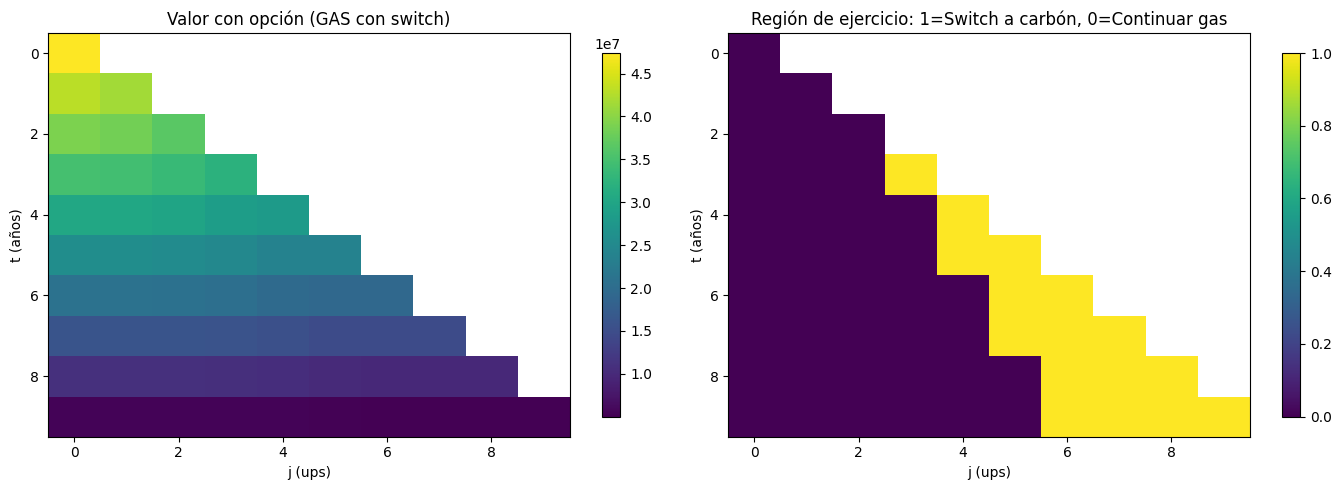

,Frac CAPEX,Switch cost (USD),Valor con switch (t=0),Prima vs GAS sin opción
0,0.00,0.000000,4.740237e+07,294567.896450
1,0.05,46837.196474,4.739752e+07,289713.571945
2,0.10,93674.392947,4.739266e+07,284859.247440
3,0.15,140511.589421,4.738781e+07,280004.922936


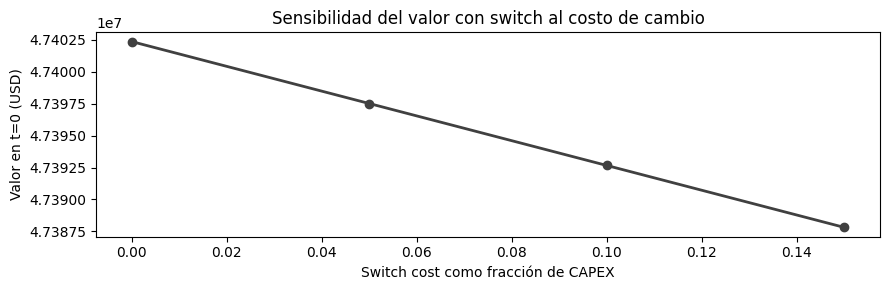

In [147]:
# -----------------------------
# (12.1) Defino costo de cambio "de mercado" (switch_cost)
# -----------------------------
# Evito “calibrar a mano” y dejo un valor fijo y defendible:
#   - regla base: 10% del CAPEX típico del cambio a gas (aprox. desmonte, readecuaciones, logística)
#   - si el CAPEX no está explícito en la serie anual 2025-2034, lo estimo como el mínimo valor numérico del sheet
#
# Dejo también una tabla de sensibilidad opcional al final (0%, 5%, 10%, 15%) sin romper el flujo principal.

vals_num = pd.to_numeric(df_gas_raw.stack(), errors="coerce").dropna()
capex_guess = abs(vals_num.min())  # suele capturar la inversión inicial negativa grande
switch_cost = 0.10 * capex_guess

print("CAPEX estimado (a partir del sheet):", capex_guess)
print("Switch cost (10% CAPEX):", switch_cost)


# -----------------------------
# (12.2) Precomputo el valor CARBÓN desde cada año t (PV a RF desde t)
# -----------------------------
# Vcoal_from_t[t] = PV en tiempo t de los flujos de carbón desde el año t hasta el final.
# Convención:
#   - decisión al inicio del año t
#   - flujo del año t se recibe al final del año => descuento 1 periodo

years_tree = np.array(years_common)     # 2025..2034
T = len(years_tree)
r = RF_USD
disc = 1.0 / (1.0 + r)

Vcoal_from_t = np.zeros(T)

for t in range(T):
    future_years = years_tree[t:]
    cfs = coa_fcf_base.loc[future_years].values
    tau = np.arange(1, len(cfs) + 1)  # 1..(T-t)
    Vcoal_from_t[t] = float(np.sum(cfs / ((1 + r) ** tau)))

# Visualización rápida (gris)
fig, ax = plt.subplots(1, 1, figsize=(9, 3))
ax.plot(years_tree, Vcoal_from_t, color="0.25", linewidth=2)
ax.set_title("CARBÓN — Valor PV a RF desde cada año t (determinístico)")
ax.set_xlabel("Año t")
ax.set_ylabel("PV en t (USD)")
ax.grid(True)
plt.tight_layout()
plt.show()


# -----------------------------
# (12.3) Construyo matriz de flujos GAS ajustados por nodo (solo flujo del año t)
# -----------------------------
# Ajuste del flujo de GAS en el año t usando el precio del nodo del árbol:
#   factor(t,j) = PriceNode(t,j) / PrecioBaseGas(t)
#   FuelAdj(t,j) = FuelBase(t) * factor(t,j)
#   FCFAdj(t,j)  = FCFBase(t) - (FuelAdj(t,j) - FuelBase(t))
#
# Usar PrecioBaseGas(t) (por año) evita comparar contra 2025 para todo el horizonte.

gas_cf_node = np.full((T, T), np.nan)

for t in range(T):
    yr = years_tree[t]
    base_unit_t = float(gas_unit_base.loc[yr])     # USD/m3 en el Excel para ese año
    fuel_base_t = float(gas_cost_base.loc[yr])     # USD en el Excel para ese año
    fcf_base_t  = float(gas_fcf_base.loc[yr])      # USD en el Excel para ese año

    for j in range(t + 1):
        price_node = float(gas_tree_price[t, j])   # USD/m3 en el nodo (árbol no homogéneo)
        factor = price_node / base_unit_t

        fuel_adj = fuel_base_t * factor
        gas_cf_node[t, j] = fcf_base_t - (fuel_adj - fuel_base_t)

# Heatmap compacto en grises
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
im = ax.imshow(gas_cf_node, aspect="auto")
ax.set_title("GAS — Flujo anual ajustado por nodo (USD)")
ax.set_xlabel("j (ups)")
ax.set_ylabel("t (años)")
fig.colorbar(im, ax=ax, shrink=0.9)
plt.tight_layout()
plt.show()


# -----------------------------
# (12.4) Backward induction: valor SIN opción (obligado a seguir en GAS)
# -----------------------------
# Vgas_no[t,j] = PV en tiempo t si se permanece en GAS siempre
# Recursión:
#   Vgas_no[t,j] = ( CF_gas(t,j) + E[Vgas_no(t+1,·)] ) / (1+r)
# Terminal:
#   Vgas_no[T-1,j] = CF_gas(T-1,j) / (1+r)

p_t = tree_gas_params["p_t"].values  # p neutral al riesgo por año

Vgas_no = np.full((T, T), np.nan)

# terminal
t_last = T - 1
for j in range(t_last + 1):
    Vgas_no[t_last, j] = disc * gas_cf_node[t_last, j]

# backward
for t in range(T - 2, -1, -1):
    for j in range(t + 1):
        cont_next = p_t[t] * Vgas_no[t + 1, j + 1] + (1 - p_t[t]) * Vgas_no[t + 1, j]
        Vgas_no[t, j] = disc * (gas_cf_node[t, j] + cont_next)


# -----------------------------
# (12.5) Backward induction: valor CON opción de switch GAS->CARBÓN
# -----------------------------
# Vopt[t,j] = max( continuar en gas, cambiar a carbón )
#   continuar = ( CF_gas(t,j) + E[Vopt(t+1,·)] ) / (1+r)
#   switch    = -switch_cost + Vcoal_from_t[t]
#
# decision[t,j] = 1 si conviene cambiar a carbón en ese nodo, 0 si conviene continuar.

Vopt = np.full((T, T), np.nan)
decision = np.full((T, T), np.nan)

# terminal
for j in range(t_last + 1):
    cont = disc * gas_cf_node[t_last, j]
    sw   = -switch_cost + Vcoal_from_t[t_last]
    Vopt[t_last, j] = max(cont, sw)
    decision[t_last, j] = 1 if sw >= cont else 0

# backward
for t in range(T - 2, -1, -1):
    for j in range(t + 1):
        cont_next = p_t[t] * Vopt[t + 1, j + 1] + (1 - p_t[t]) * Vopt[t + 1, j]
        cont = disc * (gas_cf_node[t, j] + cont_next)
        sw   = -switch_cost + Vcoal_from_t[t]

        Vopt[t, j] = max(cont, sw)
        decision[t, j] = 1 if sw >= cont else 0


# -----------------------------
# (12.6) Resultados en t=0 y chequeo de monotonía (la opción no reduce valor)
# -----------------------------
value_gas_no_option = Vgas_no[0, 0]
value_with_switch   = Vopt[0, 0]
option_premium       = value_with_switch - value_gas_no_option

print("Valor GAS sin opción (PV a RF, t=0):", value_gas_no_option)
print("Valor con opción de switch (t=0):    ", value_with_switch)
print("Prima de la flexibilidad (>=0):      ", option_premium)

# Barras en grises
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.bar(["GAS sin opción", "Con switch a carbón"], [value_gas_no_option, value_with_switch],
       color=["0.75", "0.35"])
ax.set_title("Comparación en t=0 (PV a RF)")
ax.set_ylabel("USD")
ax.grid(True, axis="y")
plt.tight_layout()
plt.show()


# -----------------------------
# (12.7) Mapas: valor y región de ejercicio (switch)
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im0 = axes[0].imshow(Vopt, aspect="auto")
axes[0].set_title("Valor con opción (GAS con switch)")
axes[0].set_xlabel("j (ups)")
axes[0].set_ylabel("t (años)")
fig.colorbar(im0, ax=axes[0], shrink=0.9)

im1 = axes[1].imshow(decision, aspect="auto", vmin=0, vmax=1)
axes[1].set_title("Región de ejercicio: 1=Switch a carbón, 0=Continuar gas")
axes[1].set_xlabel("j (ups)")
axes[1].set_ylabel("t (años)")
fig.colorbar(im1, ax=axes[1], shrink=0.9)

plt.tight_layout()
plt.show()


# -----------------------------
# (12.8) Sensibilidad opcional al switch_cost (sin cambiar el flujo principal)
# -----------------------------
# Dejo un mini-resumen para 0%, 5%, 10%, 15% de CAPEX estimado.
# La recomendación típica es reportar al menos 3 escenarios, porque el costo de cambio
# rara vez se conoce con precisión.

def value_with_switch_cost(switch_cost_test):
    Vopt_test = np.full((T, T), np.nan)

    # terminal
    for j in range(t_last + 1):
        cont = disc * gas_cf_node[t_last, j]
        sw   = -switch_cost_test + Vcoal_from_t[t_last]
        Vopt_test[t_last, j] = max(cont, sw)

    # backward
    for t in range(T - 2, -1, -1):
        for j in range(t + 1):
            cont_next = p_t[t] * Vopt_test[t + 1, j + 1] + (1 - p_t[t]) * Vopt_test[t + 1, j]
            cont = disc * (gas_cf_node[t, j] + cont_next)
            sw   = -switch_cost_test + Vcoal_from_t[t]
            Vopt_test[t, j] = max(cont, sw)

    return Vopt_test[0, 0]

sens = []
for frac in [0.00, 0.05, 0.10, 0.15]:
    sc = frac * capex_guess
    val = value_with_switch_cost(sc)
    sens.append([frac, sc, val, val - value_gas_no_option])

df_sens = pd.DataFrame(sens, columns=["Frac CAPEX", "Switch cost (USD)", "Valor con switch (t=0)", "Prima vs GAS sin opción"])
display(df_sens)

fig, ax = plt.subplots(1, 1, figsize=(9, 3))
ax.plot(df_sens["Frac CAPEX"], df_sens["Valor con switch (t=0)"], color="0.25", linewidth=2, marker="o")
ax.set_title("Sensibilidad del valor con switch al costo de cambio")
ax.set_xlabel("Switch cost como fracción de CAPEX")
ax.set_ylabel("Valor en t=0 (USD)")
#ax.grid(True), color='lightgray'
plt.tight_layout()
plt.show()

# **13. Regla de decisión del switch: región de ejercicio, precio gatillo y métricas de ejercicio**

Esta sección convierte la valoración (Sección 12) en una “política” interpretable:
1. Región de ejercicio: en qué nodos conviene hacer switch a carbón (0/1)
2. Precio gatillo (trigger) por año: umbral aproximado de precio del gas que activa el switch
3. Métricas: probabilidad neutral al riesgo de ejercer, y año esperado de ejercicio

Supuestos operativos:
- decision[t,j] ya existe (1 = switch, 0 = continuar) proveniente de la Sección 12
- gas_tree_price[t,j] es el árbol de precios del gas en USD/m3 (no homogéneo)
- p_t es el vector de probabilidades neutrales al riesgo por año (Sección 11)
- years_tree define el eje temporal (2025..2034)

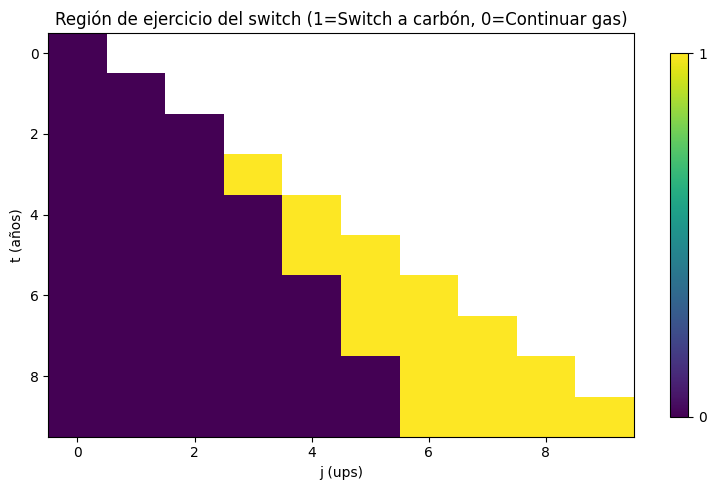

,Año,Trigger j*,Precio gatillo (USD/m3)
0,2025,NaN,NaN
1,2026,NaN,NaN
2,2027,NaN,NaN
3,2028,3.0,0.906932
4,2029,4.0,1.590517
5,2030,4.0,0.498082
6,2031,5.0,0.851012
7,2032,5.0,0.366960
8,2033,6.0,0.623898
9,2034,6.0,0.318042


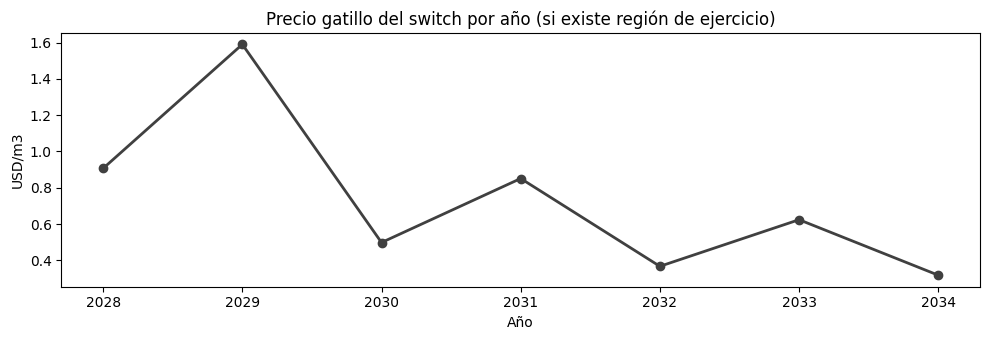

,Año,Prob(Q) ejercicio primera vez
0,2025,0.000000
1,2026,0.000000
2,2027,0.000000
3,2028,0.035981
4,2029,0.000000
5,2030,0.029696
6,2031,0.000000
7,2032,0.022463
8,2033,0.000000
9,2034,0.016991


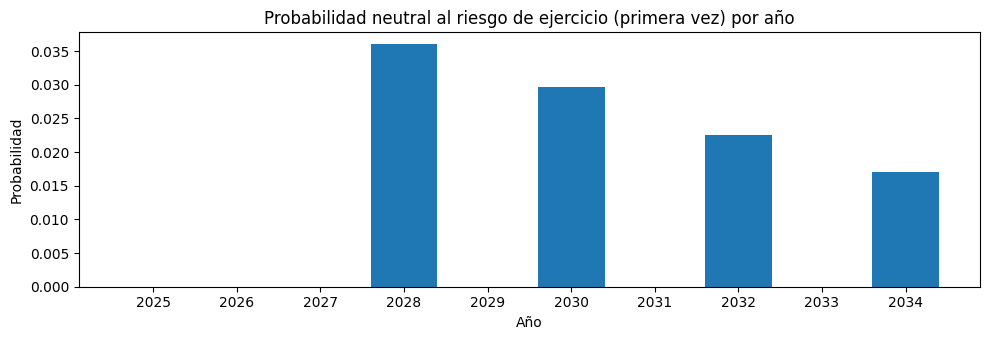

Prob(Q) de ejercer antes del final: 0.10513056870063348
Año esperado de ejercicio (condicionado a ejercer): 2030.3892851398073


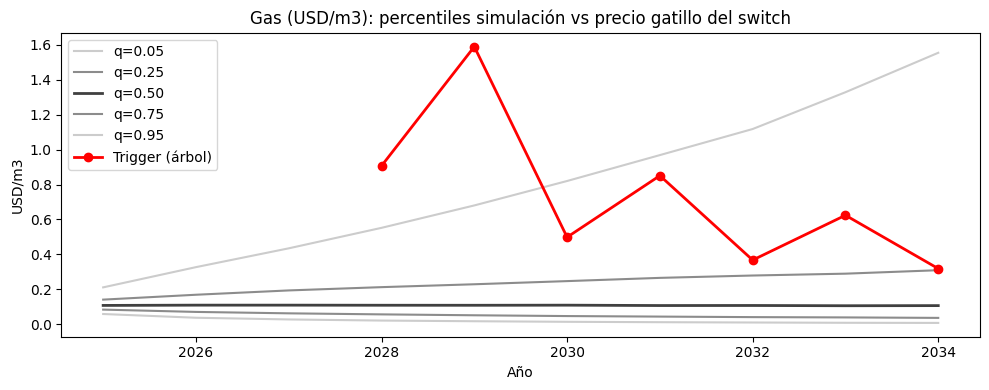

In [148]:
# -----------------------------
# (13.1) Región de ejercicio (mapa) con escala de grises
# -----------------------------
# decision[t,j] = 1 indica que en el nodo (t,j) conviene cambiar a carbón de inmediato.
# Este mapa suele ser uno de los outputs más defendibles en exposición.

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
im = ax.imshow(decision, aspect="auto", vmin=0, vmax=1)
ax.set_title("Región de ejercicio del switch (1=Switch a carbón, 0=Continuar gas)")
ax.set_xlabel("j (ups)")
ax.set_ylabel("t (años)")
cbar = fig.colorbar(im, ax=ax, shrink=0.9)
cbar.set_ticks([0, 1])
plt.tight_layout()
plt.show()


# -----------------------------
# (13.2) Precio gatillo (trigger) por año
# -----------------------------
# Se calcula un umbral aproximado por año t:
#   - entre los nodos de ese año, se identifica el primer nodo donde decision=1
#   - como el árbol es recombinante, el precio crece con j dentro de cada t
#   - si existen nodos con decisión=1, el trigger se define como el menor precio que dispara switch
#   - si no hay nodos con decisión=1, el trigger se marca como NaN (no se ejerce en ese año)

trigger_price = []
trigger_j = []

for t in range(T):
    # nodos disponibles: j=0..t
    dec_row = decision[t, :t+1]
    price_row = gas_tree_price[t, :t+1]

    idx_switch = np.where(dec_row == 1)[0]
    if len(idx_switch) == 0:
        trigger_price.append(np.nan)
        trigger_j.append(np.nan)
    else:
        j_star = int(idx_switch[0])  # menor j con switch (precio más bajo que dispara)
        trigger_j.append(j_star)
        trigger_price.append(float(price_row[j_star]))

df_trigger = pd.DataFrame({
    "Año": years_tree,
    "Trigger j*": trigger_j,
    "Precio gatillo (USD/m3)": trigger_price
})

display(df_trigger)

# Gráfica del trigger (gris)
fig, ax = plt.subplots(1, 1, figsize=(10, 3.5))
ax.plot(df_trigger["Año"], df_trigger["Precio gatillo (USD/m3)"], color="0.25", linewidth=2, marker="o")
ax.set_title("Precio gatillo del switch por año (si existe región de ejercicio)")
ax.set_xlabel("Año")
ax.set_ylabel("USD/m3")
#ax.grid(True, color='lightgray')
plt.tight_layout()
plt.show()


# -----------------------------
# (13.3) Probabilidad neutral al riesgo de ejercicio por año (primera vez)
# -----------------------------
# Se calcula la probabilidad (Q) de que el switch ocurra por primera vez en cada año.
# Para hacerlo consistentemente con el árbol:
#   - se propaga la probabilidad de llegar a cada nodo (t,j) bajo Q
#   - se define "primera vez" usando una máscara de nodos de ejercicio
#   - se evita contar nodos que se alcanzan luego de haber ejercido en un año previo
#
# Esto produce:
#   - prob_exercise_in_t: Prob(Q)[ejercicio primera vez en año t]
#   - prob_exercise_by_end: Prob(Q)[ejercicio en algún momento antes del final]
#   - expected_exercise_year: año esperado de ejercicio condicionado a que ocurra

# Probabilidad de estar en cada nodo (t,j) sin considerar ejercicio (distribución binomial no homogénea)
prob_node = np.zeros((T, T))
prob_node[0, 0] = 1.0

for t in range(T - 1):
    for j in range(t + 1):
        prob = prob_node[t, j]
        if prob == 0:
            continue
        # down -> (t+1, j)
        prob_node[t+1, j] += prob * (1 - p_t[t])
        # up -> (t+1, j+1)
        prob_node[t+1, j+1] += prob * p_t[t]

# Ahora se calcula probabilidad de "primera vez" con una DP de supervivencia (no ejercido aún)
surv = np.zeros((T, T))   # probabilidad de llegar sin haber ejercido antes
surv[0, 0] = 1.0

prob_first_ex_t = np.zeros(T)

for t in range(T):
    # probabilidad de ejercicio en año t = suma sobre nodos (prob de llegar sin ejercer) * indicador de ejercicio
    prob_first_ex_t[t] = np.nansum(surv[t, :t+1] * decision[t, :t+1])

    # propago supervivencia a t+1 solo desde nodos donde NO se ejerce en t
    if t < T - 1:
        for j in range(t + 1):
            if np.isnan(surv[t, j]) or surv[t, j] == 0:
                continue

            if decision[t, j] == 1:
                # si se ejerce aquí, no se propaga supervivencia
                continue

            p = p_t[t]
            surv[t+1, j]   += surv[t, j] * (1 - p)
            surv[t+1, j+1] += surv[t, j] * p

prob_exercise_by_end = prob_first_ex_t.sum()

# Año esperado de ejercicio (condicionado a que ocurra)
if prob_exercise_by_end > 0:
    expected_t = (np.arange(T) * prob_first_ex_t).sum() / prob_exercise_by_end
    expected_year = years_tree[0] + expected_t
else:
    expected_year = np.nan

df_ex_probs = pd.DataFrame({
    "Año": years_tree,
    "Prob(Q) ejercicio primera vez": prob_first_ex_t
})
display(df_ex_probs)

# Gráfica de probabilidad por año
fig, ax = plt.subplots(1, 1, figsize=(10, 3.5))
ax.bar(df_ex_probs["Año"].astype(str), df_ex_probs["Prob(Q) ejercicio primera vez"])
ax.set_title("Probabilidad neutral al riesgo de ejercicio (primera vez) por año")
ax.set_xlabel("Año")
ax.set_ylabel("Probabilidad")
#ax.grid(True, axis="y", color='lightgray')
plt.tight_layout()
plt.show()

print("Prob(Q) de ejercer antes del final:", float(prob_exercise_by_end))
print("Año esperado de ejercicio (condicionado a ejercer):", expected_year)


# -----------------------------
# (13.4) Extra: comparación del gatillo con bandas percentiles de simulación (contexto narrativo)
# -----------------------------
# Esta parte cruza dos mundos:
#   - umbral de ejercicio (árbol)
#   - dinámica simulada (Monte Carlo de sección 6)
#
# Se usa precio anual promedio simulado (USD/m3) para construir percentiles por año,
# y se sobrepone el trigger del árbol. Esto ayuda a explicar si el umbral es “fácil” o “difícil”
# de alcanzar bajo la dinámica estimada.

def monthly_paths_to_annual_average(paths: np.ndarray, n_years: int):
    reshaped = paths.reshape(paths.shape[0], n_years, 12)
    return reshaped.mean(axis=2)

# gas_paths_m3 viene de la Sección 8 (trayectorias mensuales ya convertidas a USD/m3)
gas_annual_avg = monthly_paths_to_annual_average(gas_paths_m3, N_YEARS)  # (n_sims, 10)

qs = [0.05, 0.25, 0.50, 0.75, 0.95]
bands = np.quantile(gas_annual_avg, qs, axis=0)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
for i, q in enumerate(qs):
    col = "0.80" if q in [0.05, 0.95] else ("0.55" if q in [0.25, 0.75] else "0.25")
    lw = 2 if q == 0.50 else 1.5
    ax.plot(years_tree, bands[i, :], color=col, linewidth=lw, label=f"q={q:.2f}")

ax.plot(df_trigger["Año"], df_trigger["Precio gatillo (USD/m3)"],
        color="red", linewidth=2, marker="o",
        label="Trigger (árbol)")

ax.set_title("Gas (USD/m3): percentiles simulación vs precio gatillo del switch")
ax.set_xlabel("Año")
ax.set_ylabel("USD/m3")
#ax.grid(True, color='lightgray')
ax.legend()
plt.tight_layout()
plt.show()